# H11 — Failed / Declined Transactions and Churn

## 1. Business Question

**Do failed or declined transactions influence user churn?**

### Hypothesis

Churn is associated with the frequency of failed or declined transactions.

### Analytical objective

Determine whether failed / declined transaction behaviour is associated with churn at user level, while distinguishing:

- descriptive association,
- statistical evidence,
- business relevance,
- and causality.

This analysis does not establish that failed / declined transactions cause churn.

## 2. Analytical Setup

### Unit of analysis

**One row per user.**

The analysis compares user-level failed / declined transaction behaviour against user-level churn status.

### Definitions

**Churned user**

A user who has previously activated NeoBank and then stops using it for **90 consecutive days**, provided the dataset has reached that date.

Users who have **never activated** are forced to `FALSE` and are not considered churn candidates. Each subsequent successful transaction resets the 90-day inactivity clock. Churn is evaluated independently of Engagement and Retention.

**Failed / declined transaction**

A transaction whose state is `FAILED` or `DECLINED`.

### Analytical variables

| Variable | Meaning |
|---|---|
| `user_id` | Unique user identifier |
| `churn_flag` | User-level churn classification |
| `failed_declined_transactions` | Number of failed / declined transactions |
| `total_transaction_count` | Total transaction count |
| `country` | User country; retained in the Mart but not used as an H11 explanatory variable |

The Mart contains the complete user-level analytical context. The analysis only selects variables required for H11.

## 3. Data & Analytical Population

The analysis uses the final validated `mart_churn` table in BigQuery.

Before analysis, the notebook verifies:

- expected columns are present,
- the dataset is one row per user,
- required analytical fields contain valid values,
- and the analytical population is established before comparison.

In [ ]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Load the validated Churn Mart directly from BigQuery.
client = bigquery.Client(project="le-wagon-da-502302")

query = '''
SELECT
    user_id,
    churn_flag,
    failed_declined_transactions,
    total_transaction_count,
    country
FROM `le-wagon-da-502302.NeoBank.mart_churn`
'''

churn = client.query(query).to_dataframe()

expected_columns = {
    "user_id",
    "churn_flag",
    "failed_declined_transactions",
    "total_transaction_count",
    "country",
}

missing_columns = expected_columns - set(churn.columns)

if missing_columns:
    raise ValueError(
        f"mart_churn is missing expected columns: {sorted(missing_columns)}"
    )

if len(churn) != churn["user_id"].nunique():
    raise ValueError("mart_churn is not one row per user.")

print("Mart shape:", churn.shape)
print("\nColumns:")
print(churn.columns.tolist())

print("\nMissing values:")
print(churn.isna().sum())

print("\nUnique users:", churn["user_id"].nunique())

Mart shape: (19430, 5)

Columns:
['user_id', 'churn_flag', 'failed_declined_transactions', 'total_transaction_count', 'country']

Missing values:
user_id                           0
churn_flag                        0
failed_declined_transactions    664
total_transaction_count         664
country                           0
dtype: int64

Unique users: 19430


In [2]:
# Keep the variables required to test H11.
analysis = churn[
    [
        "user_id",
        "churn_flag",
        "failed_declined_transactions",
        "total_transaction_count",
    ]
].copy()

analysis["churn_flag"] = analysis["churn_flag"].astype(bool)

analysis = analysis.dropna(
    subset=[
        "user_id",
        "churn_flag",
        "failed_declined_transactions",
        "total_transaction_count",
    ]
)

print("Analytical population:", len(analysis))

print("\nChurn distribution:")
print(analysis["churn_flag"].value_counts())

print("\nChurn rate:")
print(analysis["churn_flag"].mean())

Analytical population: 18766

Churn distribution:
churn_flag
False    13803
True      4963
Name: count, dtype: int64

Churn rate:
0.26446765426835767


## 4. Descriptive Evidence

Before statistical testing, compare failed / declined transaction frequency between churned and non-churned users.

Transaction counts are typically skewed, so the median and distribution are more informative than the mean alone.

In [3]:
summary = (
    analysis
    .groupby("churn_flag")["failed_declined_transactions"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        maximum="max",
    )
)

summary

,users,mean,median,q1,q3,maximum
churn_flag,,,,,,
False,13803,12.8908,7.0000,2,15,903
True,4963,3.7088,1.0000,0,4,268


/var/folders/q0/vh9t90897vd51fsk269vc_sr0000gp/T/ipykernel_78829/2949946213.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


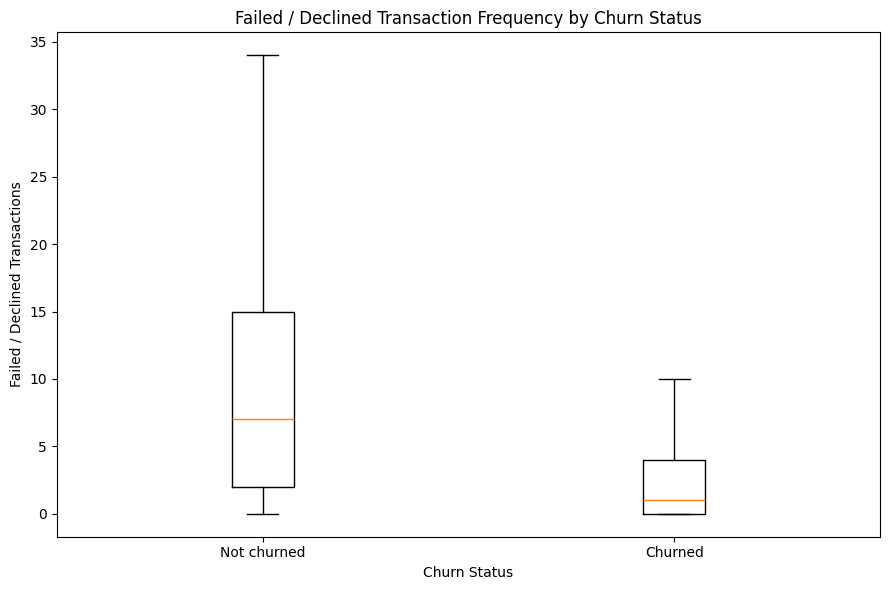

In [4]:
# Primary visual: compare the distributions by churn status.
plot_data = [
    analysis.loc[
        analysis["churn_flag"] == False,
        "failed_declined_transactions"
    ],
    analysis.loc[
        analysis["churn_flag"] == True,
        "failed_declined_transactions"
    ],
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    plot_data,
    labels=["Not churned", "Churned"],
    showfliers=False,
)

ax.set_title("Failed / Declined Transaction Frequency by Churn Status")
ax.set_ylabel("Failed / Declined Transactions")
ax.set_xlabel("Churn Status")

plt.tight_layout()
plt.show()

## 5. Statistical Evidence

The Mann–Whitney U test is used because failed / declined transaction frequency is count-based and non-normal.

The test evaluates whether the distributions differ between churned and non-churned users.

A statistically significant result indicates evidence of an association. It does not establish causality.

In [5]:
not_churned = analysis.loc[
    analysis["churn_flag"] == False,
    "failed_declined_transactions"
]

churned = analysis.loc[
    analysis["churn_flag"] == True,
    "failed_declined_transactions"
]

u_stat, p_value = mannwhitneyu(
    not_churned,
    churned,
    alternative="two-sided",
)

print(f"Mann–Whitney U: {u_stat:,.0f}")
print(f"p-value: {p_value:.6g}")

if p_value < 0.05:
    print("Result: statistically significant difference.")
else:
    print("Result: no statistically significant difference.")

Mann–Whitney U: 52,355,974
p-value: 0
Result: statistically significant difference.


## 6. Robustness Check — Failed / Declined Transaction Rate

Transaction frequency can partly reflect overall transaction activity.

To assess whether the relationship remains visible after accounting for transaction volume, calculate failed / declined transactions as a percentage of total transactions.

Users with zero total transactions are excluded because a failure rate cannot be calculated for them.

In [6]:
rate_data = analysis[
    analysis["total_transaction_count"] > 0
].copy()

rate_data["failure_rate"] = (
    rate_data["failed_declined_transactions"]
    / rate_data["total_transaction_count"]
    * 100
)

rate_summary = (
    rate_data
    .groupby("churn_flag")["failure_rate"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
)

rate_summary

,users,mean,median,q1,q3
churn_flag,,,,,
False,13803,10.1259,6.5163,2.9388,12.6050
True,4963,11.4583,5.3333,0.0000,17.6471


/var/folders/q0/vh9t90897vd51fsk269vc_sr0000gp/T/ipykernel_78829/419354559.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


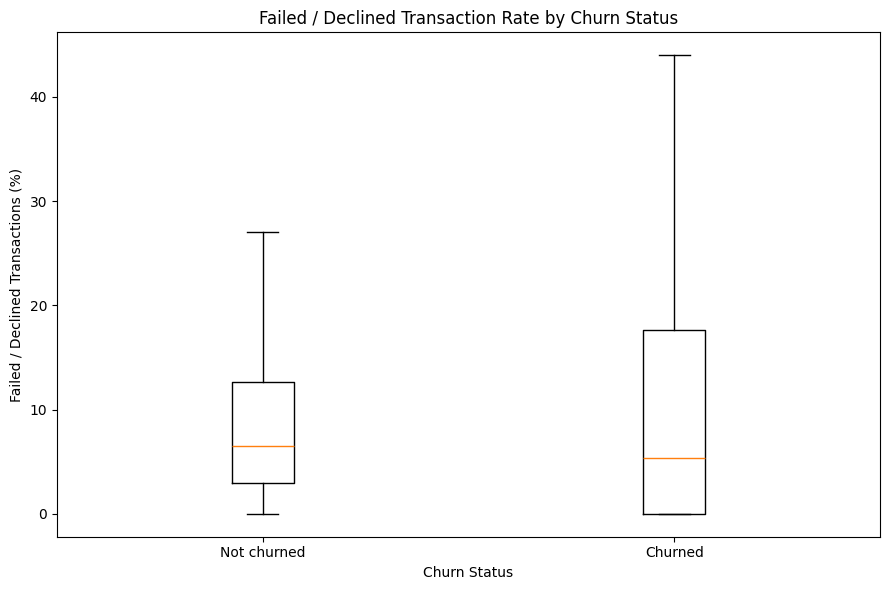

In [7]:
# Secondary visual: compare failure rates after accounting for transaction volume.
rate_plot_data = [
    rate_data.loc[
        rate_data["churn_flag"] == False,
        "failure_rate"
    ],
    rate_data.loc[
        rate_data["churn_flag"] == True,
        "failure_rate"
    ],
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    rate_plot_data,
    labels=["Not churned", "Churned"],
    showfliers=False,
)

ax.set_title("Failed / Declined Transaction Rate by Churn Status")
ax.set_ylabel("Failed / Declined Transactions (%)")
ax.set_xlabel("Churn Status")

plt.tight_layout()
plt.show()

## 7. Interpretation

The evidence should be interpreted at three levels.

### Descriptive association

Compare the distributions and central tendency of failed / declined transaction frequency between churned and non-churned users.

### Statistical evidence

Use the Mann–Whitney U result to determine whether the observed difference is statistically significant.

### Business relevance

Assess whether the observed difference is sufficiently meaningful to treat failed / declined transaction behaviour as a useful churn signal.

### Causality

This analysis is observational. It does **not** establish that failed / declined transactions cause churn.

The failure-rate analysis is a robustness check rather than a replacement for the primary frequency analysis.

## 8. Final Finding

### H11 — Partially supported / qualified association

Failed / declined transaction behaviour is associated with churn, but the evidence does not support treating failure frequency as a standalone churn driver.

The analysis provides evidence that failed / declined transaction behaviour can be considered a **churn signal**, but it does not demonstrate that reducing failed / declined transactions alone would prevent churn.

### Business-story handoff

The evidence that should move into the **Notion knowledge / business layer** is:

- the observed relationship between failed / declined behaviour and churn;
- the statistical evidence supporting the association;
- the failure-rate sensitivity check;
- the distinction between association and causality;
- and the implication that failed / declined behaviour should be considered alongside other churn factors.

The final business recommendation belongs in Notion and the presentation layer, not in this evidence notebook.